In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

checkpoints = {
    "MultVAE + L2": "TopKSAE-8192-f634db83.ckpt",
    "ELSA + L2": "TopKSAE-8192-d6337b64.ckpt",
    "ELSA + Cosine": "TopKSAE-8192-3c29e9ee.ckpt",    
}

#checkpoint = "TopKSAE-8192-f634db83.ckpt" #multvae
#checkpoint = "TopKSAE-8192-3c29e9ee.ckpt" #cosine
#checkpoint = "TopKSAE-8192-d6337b64.ckpt" #l2

# From Neurons to Tags

In [23]:
results = {}
for model, checkpoint in checkpoints.items():
    chckpt_name = checkpoint.split("-", 1)[1].replace(".ckpt", "")
    res = pd.read_csv(f"results/res_neuron_tag_{chckpt_name}.csv")
    results[model] = res


resultsT_to_N = {}
for model, checkpoint in checkpoints.items():
    chckpt_name = checkpoint.split("-", 1)[1].replace(".ckpt", "")
    res = pd.read_csv(f"results/res_tag_neuron_{chckpt_name}.csv")
    resultsT_to_N[model] = res


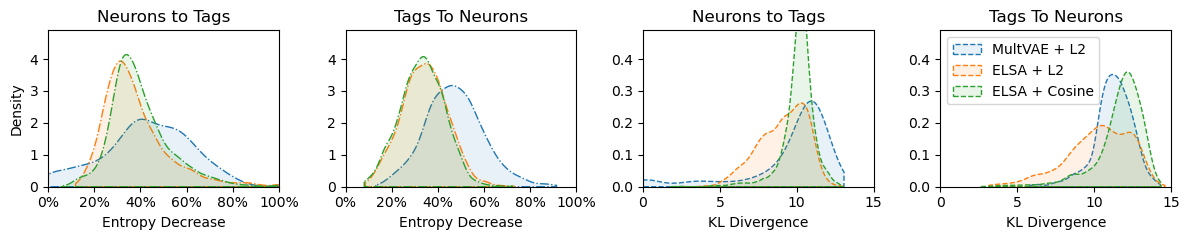

In [24]:
# Initialize the plot
fig, (ax1,ax3,ax2,ax4) = plt.subplots(1,4, figsize=(12, 2.5))
for model, res in results.items():
    min_kldiv = res['KL_div'].min()
    max_kldiv = res['KL_div'].max()
    sns.kdeplot(res["KL_div"], ax=ax2, label=model, fill=True, linestyle="--", clip=(min_kldiv, max_kldiv), alpha=0.1)


    min_entropy = res['norm_entropy_diff'].min()
    max_entropy = res['norm_entropy_diff'].max()
    sns.kdeplot(res["norm_entropy_diff"], ax=ax1, label=model, fill=True, linestyle="-.", clip=(min_entropy, max_entropy), alpha=0.1)

ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("Density (Normalized Entropy Diff)")
ax2.set_ylabel("Density (KL divergence)")


for model, res in resultsT_to_N.items():
    min_kldiv = res['KL_div'].min()
    max_kldiv = res['KL_div'].max()
    sns.kdeplot(res["KL_div"], ax=ax4, label=model, fill=True, linestyle="--", clip=(min_kldiv, max_kldiv), alpha=0.1)


    min_entropy = res['norm_entropy_diff'].min()
    max_entropy = res['norm_entropy_diff'].max()
    sns.kdeplot(res["norm_entropy_diff"], ax=ax3, label=model, fill=True, linestyle="-.", clip=(min_entropy, max_entropy), alpha=0.1)

ax1.set_xlabel("Entropy Decrease")
ax2.set_xlabel("KL Divergence")
ax3.set_xlabel("Entropy Decrease")
ax4.set_xlabel("KL Divergence")

ax1.set_ylabel("Density")
ax2.set_ylabel("")
ax3.set_ylabel("")
ax4.set_ylabel("")

ax1.set_title("Neurons to Tags")
ax2.set_title("Neurons to Tags")
ax3.set_title("Tags To Neurons")
ax4.set_title("Tags To Neurons")

ax1.set_xlim(0.0, 1.0)
ax1.set_ylim(0.0, 4.9)
ax3.set_xlim(0.0, 1.0)
ax3.set_ylim(0.0, 4.9)

ax2.set_xlim(0.0, 15)
ax2.set_ylim(0.0, 0.49)
ax4.set_xlim(0.0, 15)
ax4.set_ylim(0.0, 0.49)

# Show the legend
ax4.legend(loc="upper left")
fig.tight_layout()


ax1.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])  # Positions of the ticks
ax1.set_xticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])  # Custom labels
ax3.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])  # Positions of the ticks
ax3.set_xticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])  # Custom labels

plt.tight_layout()
plt.savefig("rq2_results.pdf",bbox_inches='tight')

In [26]:
for model, res in resultsT_to_N.items():
    res = res.sort_values("KL_div", ascending=False)
    dt = pd.concat([res.head(5)[["tag","entropy","KL_div"]],res.tail(1)[["tag","entropy","KL_div"]]])
    print(model)
    print(dt.to_latex(index=False, float_format="{:.2f}".format))



MultVAE + L2
\begin{tabular}{lrr}
\toprule
tag & entropy & KL_div \\
\midrule
james bond & 2.06 & 14.30 \\
quentin tarantino & 2.86 & 14.24 \\
studio ghibli & 1.67 & 14.16 \\
star trek & 1.64 & 14.01 \\
robert rodriguez & 1.90 & 14.00 \\
boring & 5.44 & 5.76 \\
\bottomrule
\end{tabular}

ELSA + L2
\begin{tabular}{lrr}
\toprule
tag & entropy & KL_div \\
\midrule
quentin tarantino & 4.65 & 14.60 \\
wes anderson & 4.09 & 14.25 \\
stanley kubrick & 4.50 & 14.20 \\
monty python & 3.52 & 14.04 \\
coen brothers & 4.81 & 13.99 \\
boring & 7.33 & 3.15 \\
\bottomrule
\end{tabular}

ELSA + Cosine
\begin{tabular}{lrr}
\toprule
tag & entropy & KL_div \\
\midrule
quentin tarantino & 4.90 & 14.34 \\
coen brothers & 5.21 & 14.20 \\
james bond & 5.18 & 14.20 \\
tim burton & 5.28 & 14.10 \\
jim carrey & 5.17 & 14.07 \\
bd-r & 8.22 & 2.65 \\
\bottomrule
\end{tabular}



In [27]:
for model, res in resultsT_to_N.items():
    res = res.sort_values("entropy", ascending=False)
    dt = res.head(1)[["tag","entropy","norm_entropy_diff"]]
    print(model)
    print(dt)
    print(dt.entropy/(1-dt.norm_entropy_diff))

MultVAE + L2
       tag  entropy  norm_entropy_diff
41  boring  5.44224           0.130805
41    6.261245
dtype: float64
ELSA + L2
                tag   entropy  norm_entropy_diff
61  based on a book  7.562723           0.085691
61    8.271515
dtype: float64
ELSA + Cosine
                tag   entropy  norm_entropy_diff
61  based on a book  8.277456           0.080931
61    9.006345
dtype: float64


In [31]:
for model, res in results.items():
    res = res.sort_values("entropy", ascending=False)
    print(model)
    print(res.norm_entropy_diff.mean(),res.KL_div.mean())

MultVAE + L2
0.4263594690031011 9.620590591493885
ELSA + L2
0.37760305196620225 9.107274237074364
ELSA + Cosine
0.39694028107922996 10.118500244678135


In [30]:
for model, res in resultsT_to_N.items():
    res = res.sort_values("entropy", ascending=False)
    print(model)
    print(res.norm_entropy_diff.mean(),res.KL_div.mean())

MultVAE + L2
0.471799838256394 11.237157639426997
ELSA + L2
0.3428062743606168 10.271410115576357
ELSA + Cosine
0.33223228376080366 11.654641389439634


In [28]:
for model, res in resultsT_to_N.items():
    print(model)
    print((res.KL_div>10).sum() / res.shape[0])


MultVAE + L2
0.8830373545621556
ELSA + L2
0.5939987752602572
ELSA + Cosine
0.8830373545621556
